Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['customers.csv', 'churn_labels.csv', 'web_events_snapshot.csv', 'rfm_modeling_snapshot.csv', 'intervention_history.csv', 'STUDENT_FACING_PROBLEM_STATEMENT.md', 'DATA_DICTIONARY.md', 'orders.csv', 'support_tickets.csv']
  customer_id signup_date city_tier age_group acquisition_channel  \
0   CUST00001  2024-04-24    Tier 1     18-24           Instagram   
1   CUST00002  2025-06-01    Tier 2     25-34         Marketplace   
2   CUST00003  2025-03-08    Tier 1     25-34          Influencer   
3   CUST00004  2025-04-15    Tier 3     25-34       Google Search   
4   CUST00005  2024-08-21    Tier 3     35-44             Organic   

  loyalty_tier preferred_category    skin_type marketing_consent  
0       Silver             Makeup       Normal               Yes  
1       Silver          Hair Care  Combination               Yes  
2          NaN          Skin Care  

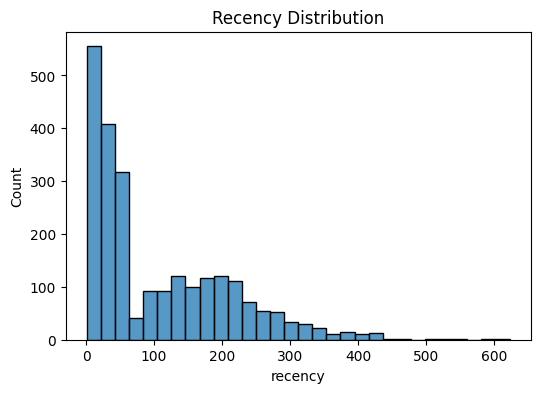

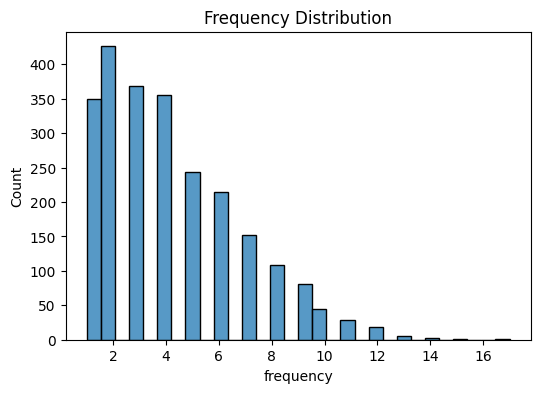

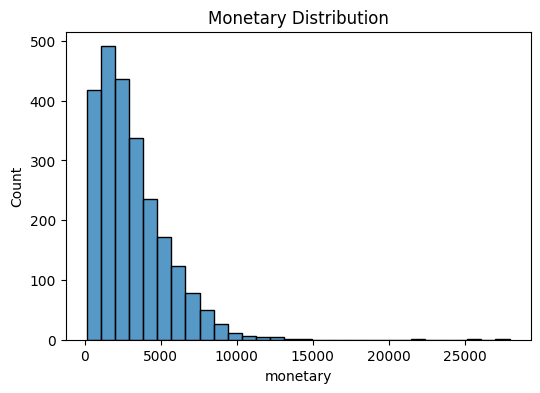

segment_name
Loyal Customers        892
Dormant Customers      716
Low Value Customers    406
Potential Loyalists    373
Champions                9
High Risk Unhappy        4
Name: count, dtype: int64


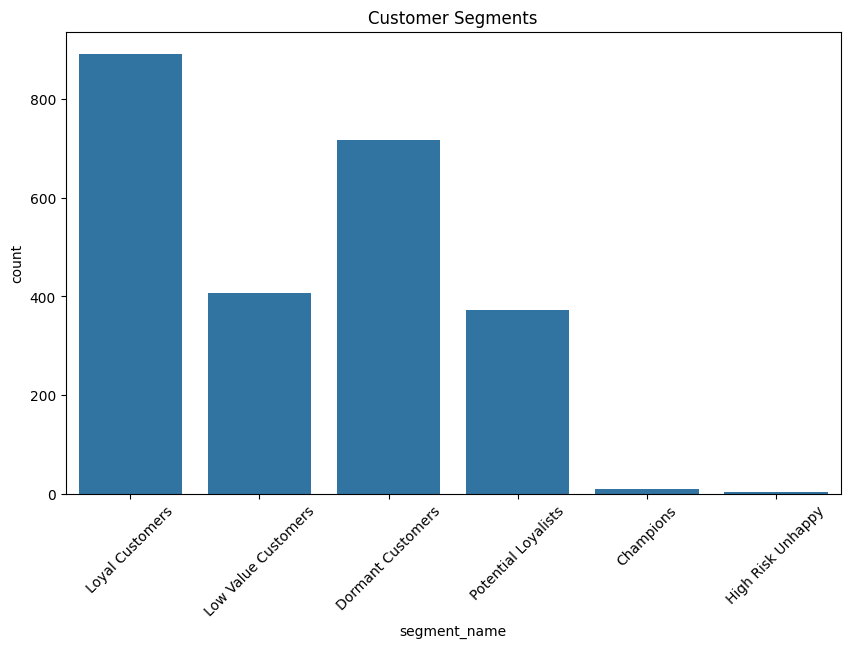

          segment_name  churn_next_60d
0            Champions        0.000000
1    Dormant Customers        1.000000
2    High Risk Unhappy        0.250000
3  Low Value Customers        0.334975
4      Loyal Customers        0.267937
5  Potential Loyalists        0.093834


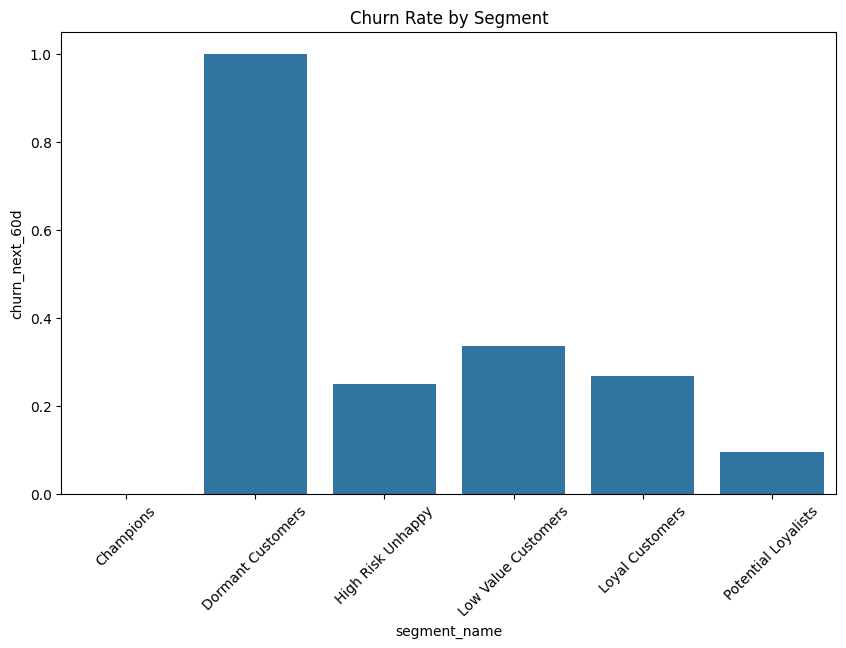

segments.csv saved successfully


In [19]:
# rfm_segmention

# Google Drive Mount

from google.colab import drive
drive.mount('/content/drive')

# Import Library

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Check Files

print(os.listdir('/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part2-rfm/data/d2c churn data package'))

# Correct Base Path

BASE_PATH = "/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part2-rfm/data/d2c churn data package/"

# Load Datasets

customers = pd.read_csv(BASE_PATH + "customers.csv")

orders = pd.read_csv(BASE_PATH + "orders.csv")

tickets = pd.read_csv(BASE_PATH + "support_tickets.csv")

campaigns = pd.read_csv(BASE_PATH + "intervention_history.csv")

labels = pd.read_csv(BASE_PATH + "churn_labels.csv")

rfm_snapshot = pd.read_csv(BASE_PATH + "rfm_modeling_snapshot.csv")

# Success Check

print(customers.head())

print(orders.head())

# Data Inspection

datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "campaigns": campaigns,
    "labels": labels
}

for name, df in datasets.items():

    print("\n", name.upper())

    print(df.shape)

    print(df.head())

#Create RFM features

# DATE CONVERSION

orders['order_date'] = pd.to_datetime(orders['order_date'])

# SNAPSHOT DATE

snapshot_date = orders['order_date'].max() + pd.Timedelta(days=1)

# CREATE RFM

rfm = orders.groupby('customer_id').agg({

    'order_date': lambda x: (snapshot_date - x.max()).days,

    'order_id': 'count',

    'gross_amount': 'sum'

}).reset_index()

# RENAME COLUMNS

rfm.columns = [
    'customer_id',
    'recency',
    'frequency',
    'monetary'
]

rfm.head()

# Calculate ticket count from tickets dataframe
ticket_counts = tickets.groupby('customer_id')['ticket_id'].count().reset_index()
ticket_counts.columns = ['customer_id', 'ticket_count']

# Merge ticket_counts into rfm dataframe
rfm = pd.merge(rfm, ticket_counts, on='customer_id', how='left')
rfm['ticket_count'] = rfm['ticket_count'].fillna(0) # Fill NaN for customers with no tickets

# Merge churn labels into rfm dataframe
rfm = pd.merge(rfm, labels[['customer_id', 'churn_next_60d']], on='customer_id', how='left')

# rfm distribution charts

plt.figure(figsize=(6,4))

sns.histplot(rfm['recency'], bins=30)

plt.title("Recency Distribution")

plt.show()


plt.figure(figsize=(6,4))

sns.histplot(rfm['frequency'], bins=30)

plt.title("Frequency Distribution")

plt.show()


plt.figure(figsize=(6,4))

sns.histplot(rfm['monetary'], bins=30)

plt.title("Monetary Distribution")

plt.show()


#Create rfm scores


rfm['R_score'] = pd.qcut(
    rfm['recency'],
    4,
    labels=[4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    4,
    labels=[1,2,3,4]
)


# final rfm scores


rfm['RFM_Score'] = (

    rfm['R_score'].astype(str) +

    rfm['F_score'].astype(str) +

    rfm['M_score'].astype(str)
)


# CREATE SEGMENTS

def segment_customer(row):

    if row['recency'] <= 30 and row['monetary'] > 10000:
        return 'Champions'

    elif row['frequency'] >= 5:
        return 'Loyal Customers'

    elif row['recency'] > 120:
        return 'Dormant Customers'

    elif row['ticket_count'] >= 3:
        return 'High Risk Unhappy'

    elif row['monetary'] < 2000:
        return 'Low Value Customers'

    else:
        return 'Potential Loyalists'


rfm['segment_name'] = rfm.apply(segment_customer, axis=1)


print(rfm['segment_name'].value_counts())


# SEGMENT COUNT CHART

plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x='segment_name'
)

plt.xticks(rotation=45)

plt.title("Customer Segments")

plt.show()

# CHURN RATE BY SEGMENT

segment_churn = rfm.groupby('segment_name')['churn_next_60d'].mean().reset_index()

print(segment_churn)


plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_churn,
    x='segment_name',
    y='churn_next_60d'
)

plt.xticks(rotation=45)

plt.title("Churn Rate by Segment")

plt.show()


# SAVE CSV FILE

rfm.to_csv(
    "/content/drive/MyDrive/D2C-CHURN-PROJECT/d2c-churn-part2-rfm/output/segments.csv",
    index=False
)

print("segments.csv saved successfully")